[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AyhamAlsuwi/Fraud-job-application-detection-model/blob/main/Real-Fake-Job-Posting%20%28used%20smote%29.ipynb)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [17]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [19]:
df  = pd.read_csv('fake_job_postings.csv')

In [20]:
df.shape

(17880, 18)

In [23]:
df = df.drop(columns='job_id')

In [25]:
df.shape

(17880, 17)

In [27]:
df.duplicated().sum()

281

In [29]:
df = df.drop_duplicates()

In [31]:
df.duplicated().sum()

0

In [33]:
inputs = df.drop(columns='fraudulent')
outputs = df['fraudulent']

In [35]:
inputs.shape , outputs.shape

((17599, 16), (17599,))

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    inputs, 
    outputs, 
    test_size=0.2, 
    random_state=42, 
    stratify=outputs
)

In [39]:
X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((14079, 16), (3520, 16), (14079,), (3520,))

In [69]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from custom_transformers import Flatten , PresenceEncoder, SalaryPresence , HighSalaryRange 

In [71]:
binary_features = ['telecommuting','has_company_logo', 'has_questions']

In [73]:
binary_pipeline = Pipeline(steps=[
    ('imputer' , SimpleImputer(strategy='most_frequent'))
])
binary_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent'))])

In [75]:
# these features have fixed classes, it is not good to make them as one hot because the model will treat one of 
# any class as always fraud if it precence with more fraud job application even if it a normal class, so
# I will use their precense rathar than the the actual class 
cat_features = ['employment_type', 'required_experience', 'required_education',  'function']

In [77]:
presence_pipeline = Pipeline(steps=[
   ('encoder' , PresenceEncoder())
])
presence_pipeline

Pipeline(steps=[('encoder', PresenceEncoder())])

In [79]:
salary_presence_pipeline = Pipeline(steps=[
    ('imputer' , SimpleImputer(strategy='constant', fill_value='unknown')),
    ('salary_presence' , SalaryPresence())
])
salary_presence_pipeline

Pipeline(steps=[('imputer',
                 SimpleImputer(fill_value='unknown', strategy='constant')),
                ('salary_presence', SalaryPresence())])

In [81]:
salary_range_pipeline = Pipeline(steps=[
    ('imputer' , SimpleImputer(strategy='constant', fill_value='unknown')),
    ('high_salary_range' , HighSalaryRange())
])
salary_range_pipeline

Pipeline(steps=[('imputer',
                 SimpleImputer(fill_value='unknown', strategy='constant')),
                ('high_salary_range', HighSalaryRange())])

In [108]:
describtion_pipeline = Pipeline(steps=[ 
    ('imputer' , SimpleImputer(strategy='constant', fill_value='unknown')),
    ('flatten' , Flatten()),
    ('TF-IDF' , TfidfVectorizer(
        analyzer='word',  ## the text has not wiered combination like 'v3rify'to choose 'char', 'word' is good.
        ngram_range=(1,2),  
        sublinear_tf=True, 
        norm='l2',
        max_df=0.8,
        min_df=0.01,
        max_features=1700,
        stop_words='english'
    ))
])
describtion_pipeline

Pipeline(steps=[('imputer',
                 SimpleImputer(fill_value='unknown', strategy='constant')),
                ('flatten', Flatten()),
                ('TF-IDF',
                 TfidfVectorizer(max_df=0.8, max_features=1700, min_df=0.01,
                                 ngram_range=(1, 2), stop_words='english',
                                 sublinear_tf=True))])

In [110]:
requirements_pipeline = Pipeline(steps=[ 
    ('imputer' , SimpleImputer(strategy='constant', fill_value='unknown')),
    ('flatten' , Flatten()),
    ('TF-IDF' , TfidfVectorizer(
        analyzer='word',  ## the text has not wiered combination like 'v3rify'to choose 'char', 'word' is good.
        ngram_range=(1,2),  
        sublinear_tf=True, 
        norm='l2',
        max_df=0.8,
        min_df=0.01,
        max_features=800,
        stop_words='english'
    ))
])
requirements_pipeline

Pipeline(steps=[('imputer',
                 SimpleImputer(fill_value='unknown', strategy='constant')),
                ('flatten', Flatten()),
                ('TF-IDF',
                 TfidfVectorizer(max_df=0.8, max_features=800, min_df=0.01,
                                 ngram_range=(1, 2), stop_words='english',
                                 sublinear_tf=True))])

In [112]:
benefits_pipeline = Pipeline(steps=[ 
    ('imputer' , SimpleImputer(strategy='constant', fill_value='unknown')),
    ('flatten' , Flatten()),
    ('TF-IDF' , TfidfVectorizer(
        analyzer='word',  ## the text has not wiered combination like 'v3rify'to choose 'char', 'word' is good.
        ngram_range=(1,2),  
        sublinear_tf=True, 
        norm='l2',
        max_df=0.8,
        min_df=0.01,
        max_features=500,
        stop_words='english'
    ))
])
benefits_pipeline

Pipeline(steps=[('imputer',
                 SimpleImputer(fill_value='unknown', strategy='constant')),
                ('flatten', Flatten()),
                ('TF-IDF',
                 TfidfVectorizer(max_df=0.8, max_features=500, min_df=0.01,
                                 ngram_range=(1, 2), stop_words='english',
                                 sublinear_tf=True))])

In [114]:
from sklearn.compose import ColumnTransformer

In [116]:
preprocessing = ColumnTransformer(
    transformers=[
        ('title_salary', salary_presence_pipeline, ['title']),
        ('company_profile_salary' ,salary_presence_pipeline , ['company_profile'] ),
        
        

        ('salary_range', salary_range_pipeline, ['salary_range']),

        ('requirements_text', requirements_pipeline, ['requirements']), 
         ('description_text', describtion_pipeline, ['description']), 
       ('benefits_text', benefits_pipeline, ['benefits']),


       
        ('num', binary_pipeline, binary_features),

        
        ('location', presence_pipeline, ['location']),
        ('company_profile', presence_pipeline, ['company_profile']), 
        ('required_education', presence_pipeline, ['required_education']),
        ('required_experience', presence_pipeline, ['required_experience']),
        ('employment_type', presence_pipeline, ['employment_type']),
        ('industry', presence_pipeline, ['industry']),
        ('function', presence_pipeline, ['function'])


    ]
)

preprocessing

ColumnTransformer(transformers=[('title_salary',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(fill_value='unknown',
                                                                strategy='constant')),
                                                 ('salary_presence',
                                                  SalaryPresence())]),
                                 ['title']),
                                ('company_profile_salary',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(fill_value='unknown',
                                                                strategy='constant')),
                                                 ('salary_presence',
                                                  SalaryPresence())]),
                                 ['company_profile']...
                                 ['required_education']),
                                ('required_experience',
                                 Pipeline(steps=[('encoder',
                                                  PresenceEncoder())]),
                                 ['required_experience']),
                                ('employment_type',
                                 Pipeline(steps=[('encoder',
                                                  PresenceEncoder())]),
                                 ['employment_type']),
                                ('industry',
                                 Pipeline(steps=[('encoder',
                                                  PresenceEncoder())]),
                                 ['industry']),
                                ('function',
                                 Pipeline(steps=[('encoder',
                                                  PresenceEncoder())]),
                                 ['function'])])

In [118]:
pre  = preprocessing.fit_transform(X_train)

In [119]:
pre.shape

(14079, 2882)

# logistic reg.(base line testing)

In [123]:
from imblearn.pipeline import Pipeline as imbPipeline
from imblearn.over_sampling import SMOTE

In [153]:
from sklearn.linear_model import LogisticRegression
logistic_reg = imbPipeline(steps=[
    ('preprocessing', preprocessing),
    ('smote' , SMOTE(random_state=42 )),
    ('logistic_reg', LogisticRegression( random_state=42 , max_iter=1000))
])
logistic_reg

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('title_salary',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='unknown',
                                                                                 strategy='constant')),
                                                                  ('salary_presence',
                                                                   SalaryPresence())]),
                                                  ['title']),
                                                 ('company_profile_salary',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='unknown',
                                                                                 strategy='constant')),
                                                                  ('salary_presence',
                                                                   Salary...
                                                  ['required_experience']),
                                                 ('employment_type',
                                                  Pipeline(steps=[('encoder',
                                                                   PresenceEncoder())]),
                                                  ['employment_type']),
                                                 ('industry',
                                                  Pipeline(steps=[('encoder',
                                                                   PresenceEncoder())]),
                                                  ['industry']),
                                                 ('function',
                                                  Pipeline(steps=[('encoder',
                                                                   PresenceEncoder())]),
                                                  ['function'])])),
                ('smote', SMOTE(random_state=42)),
                ('logistic_reg',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [155]:
from sklearn.model_selection import  cross_validate

scoring = ['precision', 'recall', 'f1' , 'average_precision','neg_log_loss']

cv_results_logistic = cross_validate(
    logistic_reg, 
    X_train, Y_train, 
    cv=3, 
    scoring=scoring, 
    return_train_score=True, 
    n_jobs=15,
    verbose = 3
)


[Parallel(n_jobs=15)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=15)]: Done   3 out of   3 | elapsed:   26.3s finished


In [157]:
cv_results_logistic['train_precision'].mean() , cv_results_logistic['test_precision'].mean() , 

(0.7523653333982717, 0.5739716455169069)

In [159]:
cv_results_logistic['train_recall'].mean() , cv_results_logistic['test_recall'].mean() , 

(0.9948910386835067, 0.7926785668684083)

In [161]:
cv_results_logistic['train_f1'].mean() , cv_results_logistic['test_f1'].mean() , 

(0.856741930634914, 0.6653429407240595)

In [163]:
cv_results_logistic['train_average_precision'].mean() , cv_results_logistic['test_average_precision'].mean()

(0.9828639915950372, 0.7807822164714646)

In [165]:
logistic_reg.fit(X_train,Y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('title_salary',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='unknown',
                                                                                 strategy='constant')),
                                                                  ('salary_presence',
                                                                   SalaryPresence())]),
                                                  ['title']),
                                                 ('company_profile_salary',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='unknown',
                                                                                 strategy='constant')),
                                                                  ('salary_presence',
                                                                   Salary...
                                                  ['required_experience']),
                                                 ('employment_type',
                                                  Pipeline(steps=[('encoder',
                                                                   PresenceEncoder())]),
                                                  ['employment_type']),
                                                 ('industry',
                                                  Pipeline(steps=[('encoder',
                                                                   PresenceEncoder())]),
                                                  ['industry']),
                                                 ('function',
                                                  Pipeline(steps=[('encoder',
                                                                   PresenceEncoder())]),
                                                  ['function'])])),
                ('smote', SMOTE(random_state=42)),
                ('logistic_reg',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [197]:
preprocessor = logistic_reg.named_steps['preprocessing']
log_reg_model = logistic_reg.named_steps['logistic_reg']

# 2. Get the feature names (the 3,000 words + your metadata) and the coefficients
# get_feature_names_out() automatically handles ColumnTransformer outputs
feature_names = preprocessor.get_feature_names_out()
coefficients = log_reg_model.coef_[0]

# 3. Bind them together in a DataFrame
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Weight': coefficients
})



# 4. Isolate the extremes (Top 20 Fraud, Top 20 Real)
# Positive weights push the probability toward 1 (Fraud)
top_fraud = feature_importance.sort_values(by='Weight', ascending=False).head(30)

# Negative weights push the probability toward 0 (Real)
top_real = feature_importance.sort_values(by='Weight', ascending=True).head(30)

In [199]:
top_fraud

,Feature,Weight
1693,description_text__link,5.767185
1289,description_text__earn,4.667356
1798,description_text__money,3.762098
91,requirements_text__clean,3.477942
315,requirements_text__high school,3.443989
2865,benefits_text__work life,3.290270
1,company_profile_salary__has_salary,3.238729
2396,description_text__type,3.174779
1380,description_text__experience required,3.116008
1090,description_text__company,3.090936


In [201]:
top_real

,Feature,Weight
1701,description_text__ll,-3.181648
219,requirements_text__english,-3.109763
589,requirements_text__reliable,-2.718832
799,requirements_text__years,-2.607946
1495,description_text__growth,-2.485267
966,description_text__based,-2.383962
1940,description_text__plus,-2.325342
2459,description_text__web,-2.305101
1492,description_text__growing,-2.292479
2139,description_text__right,-2.289708


# XGB

In [204]:
from xgboost import XGBClassifier

xgb = imbPipeline(steps=[
    ('preprocessing', preprocessing),
    ('smote' , SMOTE(random_state=42 )),
    ('xgb', XGBClassifier(    random_state=42 ))
])
xgb

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('title_salary',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='unknown',
                                                                                 strategy='constant')),
                                                                  ('salary_presence',
                                                                   SalaryPresence())]),
                                                  ['title']),
                                                 ('company_profile_salary',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='unknown',
                                                                                 strategy='constant')),
                                                                  ('salary_presence',
                                                                   Salary...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [206]:
from sklearn.model_selection import  cross_validate

scoring = ['precision', 'recall', 'f1' , 'average_precision','neg_log_loss']

cv_results_xgb = cross_validate(
    xgb, 
    X_train, Y_train, 
    cv=3, 
    scoring=scoring, 
    return_train_score=True, 
    n_jobs=15,
    verbose = 3
)


[Parallel(n_jobs=15)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=15)]: Done   3 out of   3 | elapsed:   56.6s finished


In [212]:
cv_results_xgb['train_precision'].mean() , cv_results_xgb['test_precision'].mean() , 

(1.0, 0.8485221674876847)

In [214]:
cv_results_xgb['train_recall'].mean() , cv_results_xgb['test_recall'].mean() , 

(0.9883152904142193, 0.6394060113894634)

In [210]:
cv_results_xgb['train_f1'].mean() , cv_results_xgb['test_f1'].mean() , 

(0.9941100009413423, 0.7292266391929368)

In [216]:
cv_results_xgb['train_average_precision'].mean() , cv_results_xgb['test_average_precision'].mean()

(0.9997620919133118, 0.7941945617919289)

In [219]:
xgb.fit(X_train, Y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('title_salary',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='unknown',
                                                                                 strategy='constant')),
                                                                  ('salary_presence',
                                                                   SalaryPresence())]),
                                                  ['title']),
                                                 ('company_profile_salary',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='unknown',
                                                                                 strategy='constant')),
                                                                  ('salary_presence',
                                                                   Salary...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [220]:
sorted(zip(xgb['xgb'].feature_importances_ , xgb['preprocessing'].get_feature_names_out() ), reverse=True)

[(0.04902998, 'description_text__corporate'),
 (0.047200188, 'description_text__gas'),
 (0.042055123, 'company_profile__company_profile_has_value'),
 (0.031019136, 'benefits_text__advancement'),
 (0.027679196, 'requirements_text__engineering'),
 (0.026321312, 'requirements_text__internet'),
 (0.024897372, 'benefits_text__working environment'),
 (0.022364326, 'benefits_text__stock'),
 (0.019948725, 'benefits_text__perks'),
 (0.019837942, 'description_text__assists'),
 (0.01895305, 'company_profile_salary__has_salary'),
 (0.01291445, 'requirements_text__daily'),
 (0.012745189, 'description_text__maintenance'),
 (0.0118858535, 'description_text__ensure'),
 (0.011289219, 'description_text__30'),
 (0.009565031, 'description_text__web'),
 (0.00942582, 'requirements_text__high school'),
 (0.009015768, 'description_text__control'),
 (0.0089861285, 'description_text__developer'),
 (0.00817896, 'requirements_text__home'),
 (0.008052192, 'description_text__growing'),
 (0.007912336, 'description_t

# V2

In [225]:
from xgboost import XGBClassifier

xgb_v2 = imbPipeline(steps=[
    ('preprocessing', preprocessing),
    ('smote' , SMOTE(random_state=42 )),
    ('xgb', XGBClassifier(    random_state=42 ))
])
xgb_v2

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('title_salary',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='unknown',
                                                                                 strategy='constant')),
                                                                  ('salary_presence',
                                                                   SalaryPresence())]),
                                                  ['title']),
                                                 ('company_profile_salary',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='unknown',
                                                                                 strategy='constant')),
                                                                  ('salary_presence',
                                                                   Salary...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [227]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist = {
    'xgb__n_estimators': randint(200,500),
    'xgb__max_depth': [3, 4, 5, 7,9], 
    'xgb__colsample_bytree': [0.3, 0.4, 0.5, 0.6], 
    'xgb__learning_rate': [0.01, 0.05, 0.1, 0.2],
}

random_search_xgb_v2 = RandomizedSearchCV(
    estimator=xgb_v2,                  
    param_distributions=param_dist,    
    n_iter=30,                         
    scoring='average_precision',       
    cv=3,                              
    verbose=3,                         
    n_jobs=15,                         
    random_state=42                    
)
random_search_xgb_v2.fit(X_train, Y_train)


Fitting 3 folds for each of 30 candidates, totalling 90 fits


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessing',
                                              ColumnTransformer(transformers=[('title_salary',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(fill_value='unknown',
                                                                                                              strategy='constant')),
                                                                                               ('salary_presence',
                                                                                                SalaryPresence())]),
                                                                               ['title']),
                                                                              ('company_profile_salary',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(fill_value='unknown',
                                                                                                              strategy='con...
                                                            n_jobs=None,
                                                            num_parallel_tree=None, ...))]),
                   n_iter=30, n_jobs=15,
                   param_distributions={'xgb__colsample_bytree': [0.3, 0.4, 0.5,
                                                                  0.6],
                                        'xgb__learning_rate': [0.01, 0.05, 0.1,
                                                               0.2],
                                        'xgb__max_depth': [3, 4, 5, 7, 9],
                                        'xgb__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000002574C7D01D0>},
                   random_state=42, scoring='average_precision', verbose=3)

In [229]:
xgb_v2 = random_search_xgb_v2.best_estimator_

In [231]:
best_params = random_search_xgb_v2.best_params_
best_params

{'xgb__colsample_bytree': 0.3,
 'xgb__learning_rate': 0.1,
 'xgb__max_depth': 9,
 'xgb__n_estimators': 366}

In [233]:
from sklearn.model_selection import  cross_validate

scoring = ['precision', 'recall', 'f1' , 'average_precision','neg_log_loss']

cv_results_xgb_v2 = cross_validate(
    xgb_v2, 
    X_train, Y_train, 
    cv=3, 
    scoring=scoring, 
    return_train_score=True, 
    n_jobs=15,
    verbose = 3
)


[Parallel(n_jobs=15)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=15)]: Done   3 out of   3 | elapsed:  1.9min finished


In [243]:
cv_results_xgb_v2['train_precision'].mean() , cv_results_xgb_v2['test_precision'].mean() , 

(1.0, 0.9082346977916598)

In [241]:
cv_results_xgb_v2['train_recall'].mean() , cv_results_xgb_v2['test_recall'].mean() , 

(0.9985396112454733, 0.636507571694885)

In [239]:
cv_results_xgb_v2['train_f1'].mean() , cv_results_xgb_v2['test_f1'].mean() , 

(0.9992690049690829, 0.7482206701127924)

In [235]:
cv_results_xgb_v2['train_average_precision'].mean() , cv_results_xgb_v2['test_average_precision'].mean()

(1.0, 0.8197294568468028)

# V3

In [252]:
from xgboost import XGBClassifier

xgb_v3 = imbPipeline(steps=[
    ('preprocessing', preprocessing),
    ('smote' , SMOTE(random_state=42 )),
    ('xgb', XGBClassifier(    random_state=42 ))
])
xgb_v3

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('title_salary',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='unknown',
                                                                                 strategy='constant')),
                                                                  ('salary_presence',
                                                                   SalaryPresence())]),
                                                  ['title']),
                                                 ('company_profile_salary',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='unknown',
                                                                                 strategy='constant')),
                                                                  ('salary_presence',
                                                                   Salary...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [254]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'xgb__n_estimators': [390],
    'xgb__max_depth': [5,7,9,11], 
    'xgb__colsample_bytree': [0.4,0.6], 
    'xgb__learning_rate': [.1],
}


grid_search_xgb_v3 = GridSearchCV(
    estimator=xgb_v3,
    param_grid=param_grid,
    scoring='average_precision', 
    cv=3,
    n_jobs=15,                  
    verbose=3                   
)

grid_search_xgb_v3.fit(X_train,Y_train)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('title_salary',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(fill_value='unknown',
                                                                                                        strategy='constant')),
                                                                                         ('salary_presence',
                                                                                          SalaryPresence())]),
                                                                         ['title']),
                                                                        ('company_profile_salary',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(fill_value='unknown',
                                                                                                        strategy='constant'...
                                                      max_delta_step=None,
                                                      max_depth=None,
                                                      max_leaves=None,
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=None,
                                                      num_parallel_tree=None, ...))]),
             n_jobs=15,
             param_grid={'xgb__colsample_bytree': [0.4, 0.6],
                         'xgb__learning_rate': [0.1],
                         'xgb__max_depth': [5, 7, 9, 11],
                         'xgb__n_estimators': [390]},
             scoring='average_precision', verbose=3)

In [256]:
xgb_v3 = grid_search_xgb_v3.best_estimator_

In [258]:
best_params_v3 = grid_search_xgb_v3.best_params_
best_params_v3

{'xgb__colsample_bytree': 0.6,
 'xgb__learning_rate': 0.1,
 'xgb__max_depth': 11,
 'xgb__n_estimators': 390}

In [260]:
from sklearn.model_selection import  cross_validate

scoring = ['precision', 'recall', 'f1' , 'average_precision','neg_log_loss']

cv_results_xgb_v3 = cross_validate(
    xgb_v3, 
    X_train, Y_train, 
    cv=3, 
    scoring=scoring, 
    return_train_score=True, 
    n_jobs=15,
    verbose = 3
)


[Parallel(n_jobs=15)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=15)]: Done   3 out of   3 | elapsed:  2.9min finished


In [268]:
cv_results_xgb_v3['train_precision'].mean() , cv_results_xgb_v3['test_precision'].mean() , 

(1.0, 0.9038472011514372)

In [266]:
cv_results_xgb_v3['train_recall'].mean() , cv_results_xgb_v3['test_recall'].mean() , 

(1.0, 0.6598483107331647)

In [264]:
cv_results_xgb_v3['train_f1'].mean() , cv_results_xgb_v3['test_f1'].mean() , 

(1.0, 0.762740789609993)

In [262]:
cv_results_xgb_v3['train_average_precision'].mean() , cv_results_xgb_v3['test_average_precision'].mean()

(1.0, 0.8230782332404623)

In [270]:
model = xgb_v3

In [272]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve

In [274]:
probabilities = cross_val_predict(
    model, 
    X_train, 
    Y_train, 
    cv=3, # Use the same CV number you used in tuning
    method='predict_proba',
    n_jobs=15
)

In [275]:
fraud_probas = probabilities[:,1]
fraud_probas

array([7.4545377e-01, 4.2930356e-04, 3.5367589e-04, ..., 4.9276005e-05,
       2.3288815e-04, 1.5198129e-04], dtype=float32)

In [276]:
precisions, recalls, thresholds = precision_recall_curve(Y_train, fraud_probas)

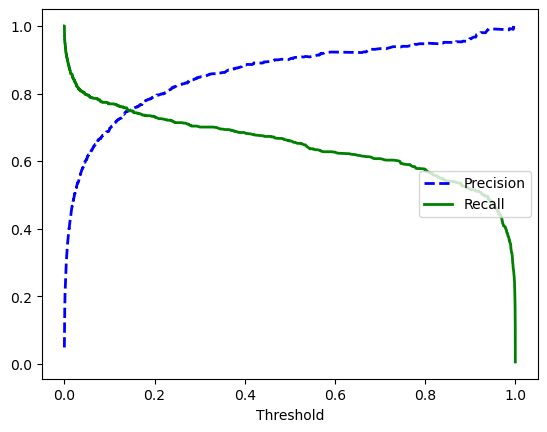

In [277]:
plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
plt.xlabel("Threshold")
plt.legend(loc="center right");

## finding the best mathmatical threshold (highest f1 score)

In [279]:
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)

In [280]:
optimal_f1_idx = np.argmax(f1_scores)
best_f1_threshold = thresholds[optimal_f1_idx]
best_f1_threshold

0.36393094

In [281]:
f1_scores[optimal_f1_idx] , precisions[optimal_f1_idx] , recalls[optimal_f1_idx]

(0.7717303000750184, 0.86996336996337, 0.6934306569343066)

In [282]:
from custom_transformers import ThresholdWrapper
from sklearn.metrics import ConfusionMatrixDisplay

In [291]:
best_f1_score_model = ThresholdWrapper(pipeline= model , threshold=0.36)

## best auto banner threshold (high precision)

In [305]:
precision_95_idx = np.argmax(precisions >=0.95)
precision_95_threshold = thresholds[precision_95_idx]
precision_95_threshold

0.84167635

In [307]:
recalls[precision_95_idx] 

0.545985401459854

In [309]:
auto_banner_model = ThresholdWrapper(pipeline= model , threshold=0.8)

## best threshold for initial filtering (high recall)

In [323]:
recall_80_idx = np.argmax(recalls <=0.75)
recall_80_threshold = thresholds[recall_80_idx]
recall_80_threshold

0.14449798

In [325]:
precisions[recall_80_idx]

0.7489051094890511

In [327]:
initial_filtering_model = ThresholdWrapper(pipeline= model , threshold=0.15)

# Test set

In [330]:
from sklearn.metrics import (
    precision_score, 
    recall_score, 
    f1_score, 
)

In [332]:
# best f1 score model

best_f1_score_pred = best_f1_score_model.predict(X_test)


best_f1_precision = precision_score(Y_test, best_f1_score_pred)
best_f1_recall = recall_score(Y_test, best_f1_score_pred)
best_f1_f1 = f1_score(Y_test, best_f1_score_pred)

best_f1_precision ,best_f1_recall ,best_f1_f1

(0.8840579710144928, 0.7134502923976608, 0.7896440129449838)

In [334]:
# auto banner 

auto_banner_pred = auto_banner_model.predict(X_test)

auto_banner_precision = precision_score(Y_test, auto_banner_pred)
auto_banner_recall = recall_score(Y_test, auto_banner_pred)
auto_banner_f1 = f1_score(Y_test, auto_banner_pred)

auto_banner_precision ,auto_banner_recall , auto_banner_f1

(0.9727272727272728, 0.6257309941520468, 0.7615658362989324)

In [338]:
# initial filter

init_filter_pred = initial_filtering_model.predict(X_test)

init_filter_precision = precision_score(Y_test, init_filter_pred)
init_filter_recall = recall_score(Y_test, init_filter_pred)
init_filter_f1 = f1_score(Y_test, init_filter_pred)

init_filter_precision , init_filter_recall , init_filter_f1

(0.7965116279069767, 0.8011695906432749, 0.7988338192419825)